# Practical Statistics for Data Scientists - Chapter 1
## Exploratory Data Analysis (EDA)

This notebook covers key exploratory data analysis techniques including estimates of location, estimates of variability, distribution analysis, and multivariate relationships using Python.

### Environment Setup and Imports

In [25]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

!pip install wquantiles
import wquantiles

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

---

## 1. Estimates of Location (Central Tendency)

Explore metrics to quantify the center of a feature distribution: **Mean**, **Trimmed Mean**, **Median**, **Weighted Mean**, and **Weighted Median**.

### Load Dataset

In [26]:
state = pd.read_csv('/content/state.csv')

### Location Estimates for Population

In [27]:
mean_pop = state['Population'].mean()
trimmed_mean_pop = stats.trim_mean(state['Population'], proportiontocut=0.10)
median_pop = state['Population'].median()

print(f"Mean Population: {mean_pop:,.0f}")
print(f"10% Trimmed Mean Population: {trimmed_mean_pop:,.0f}")
print(f"Median Population: {median_pop:,.0f}")

Mean Population: 6,162,876
10% Trimmed Mean Population: 4,783,697
Median Population: 4,436,370


### Weighted Estimates for Murder Rate

In [28]:
weighted_mean_rate = np.average(state['Murder.Rate'], weights=state['Population'])
weighted_median_rate = wquantiles.median(state['Murder.Rate'], weights=state['Population'])

print(f"Weighted Mean Murder Rate: {weighted_mean_rate:.2f}")
print(f"Weighted Median Murder Rate: {weighted_median_rate:.2f}")

Weighted Mean Murder Rate: 4.45
Weighted Median Murder Rate: 4.40


---

## 2. Estimates of Variability (Spread)

Quantify whether the data values are tightly clustered or spread out using **Standard Deviation**, **Interquartile Range (IQR)**, and **Median Absolute Deviation (MAD)**.

### Variability Estimates for Population

In [29]:
std_dev = state['Population'].std()
iqr = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)
mad = stats.median_abs_deviation(state['Population'], scale='normal')

print(f"Standard Deviation: {std_dev:,.0f}")
print(f"Interquartile Range (IQR): {iqr:,.0f}")
print(f"Median Absolute Deviation (MAD): {mad:,.0f}")

Standard Deviation: 6,848,235
Interquartile Range (IQR): 4,847,308
Median Absolute Deviation (MAD): 3,849,876


---

## 3. Exploring the Data Distribution

Visualize and summarize the overall structure of numeric variables using **Percentiles**, **Boxplots**, **Frequency Tables**, **Histograms**, and **Density Plots**.

### Percentiles

In [30]:
percentiles = state['Murder.Rate'].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
print("Murder Rate Percentiles:")
print(percentiles)

Murder Rate Percentiles:
0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


### Boxplot of Population

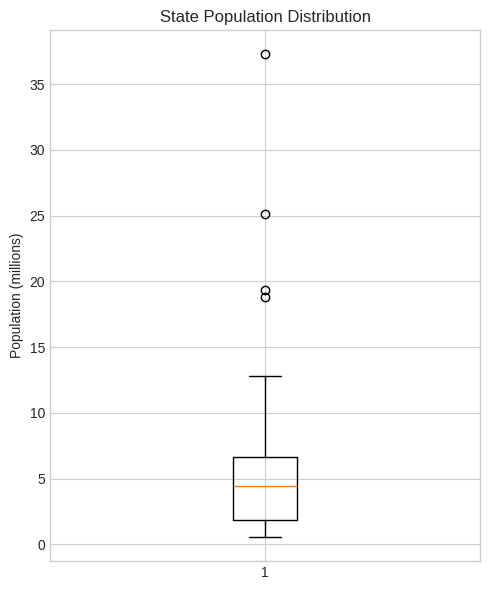

In [31]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.boxplot(state['Population'] / 1_000_000)
ax.set_ylabel('Population (millions)')
ax.set_title('State Population Distribution')
plt.tight_layout()
plt.show()

### Frequency Table and Histogram

Population Frequency Table:
Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64


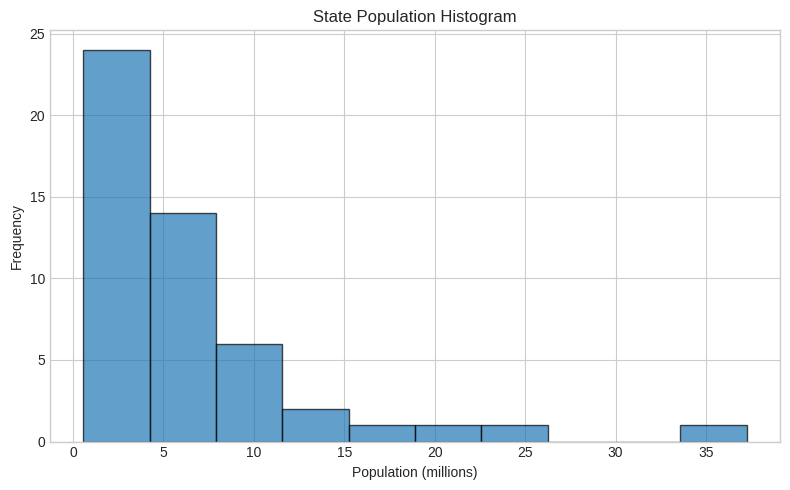

In [32]:
binned_population = pd.cut(state['Population'], bins=10)
print("Population Frequency Table:")
print(binned_population.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(state['Population'] / 1_000_000, bins=10, edgecolor='black', alpha=0.7)
ax.set_xlabel('Population (millions)')
ax.set_ylabel('Frequency')
ax.set_title('State Population Histogram')
plt.tight_layout()
plt.show()

### Density Plot

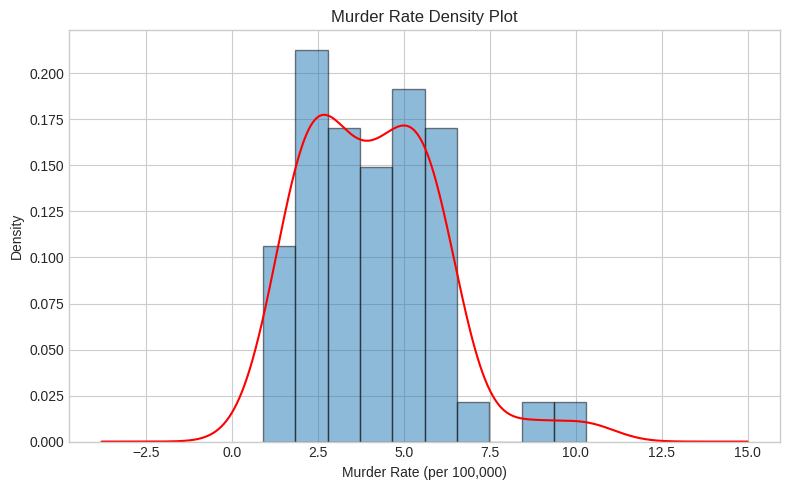

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
state['Murder.Rate'].plot.hist(density=True, ax=ax, bins=10, alpha=0.5, edgecolor='black')
state['Murder.Rate'].plot.kde(ax=ax, color='red')
ax.set_xlabel('Murder Rate (per 100,000)')
ax.set_title('Murder Rate Density Plot')
plt.tight_layout()
plt.show()

---

## 4. Exploring Two or More Variables

Analyze relationships between pairs of variables (and multiple variables) using **Correlation Matrices**, **Hexagonal Binning**, and **Categorical Boxplots**.

### Correlation Heatmap

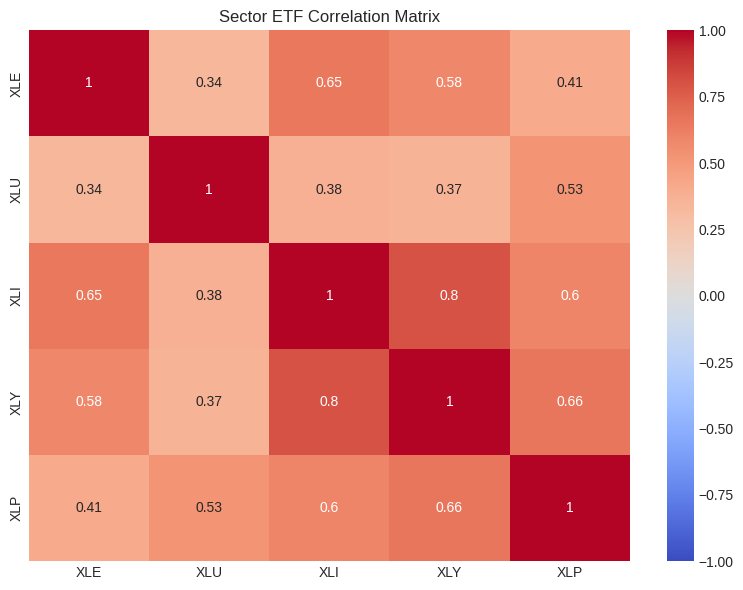

In [38]:
sp500_px = pd.read_csv('/content/sp500_data.csv', index_col=0)
etfs = sp500_px.loc[sp500_px.index >= '2012-07-01', ['XLE', 'XLU', 'XLI', 'XLY', 'XLP']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(etfs.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Sector ETF Correlation Matrix')
plt.tight_layout()
plt.show()

### Hexagonal Binning

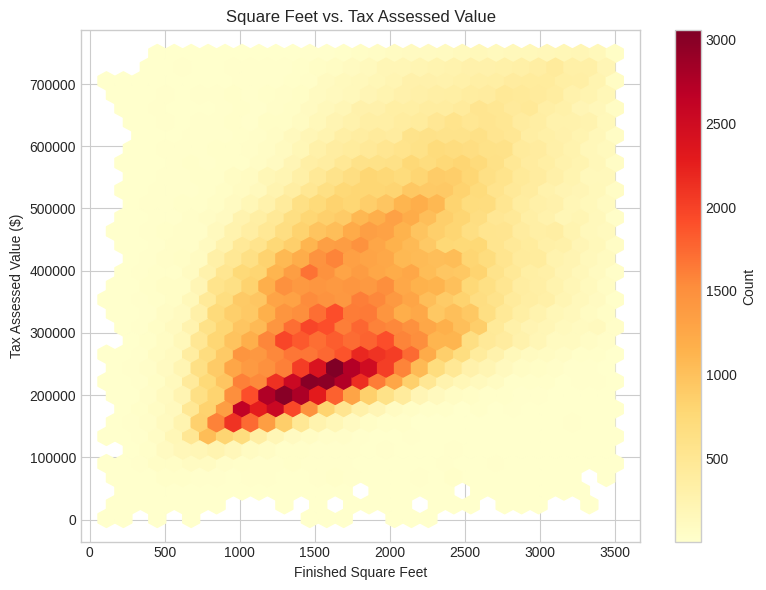

In [39]:
kc_tax = pd.read_csv('/content/kc_tax.csv')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                    (kc_tax.SqFtTotLiving > 100) &
                    (kc_tax.SqFtTotLiving < 3500), :]

fig, ax = plt.subplots(figsize=(8, 6))
hexbin = ax.hexbin(kc_tax0['SqFtTotLiving'], kc_tax0['TaxAssessedValue'],
                   gridsize=30, cmap='YlOrRd', mincnt=1)
fig.colorbar(hexbin, ax=ax, label='Count')
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value ($)')
ax.set_title('Square Feet vs. Tax Assessed Value')
plt.tight_layout()
plt.show()

### Categorical Comparison

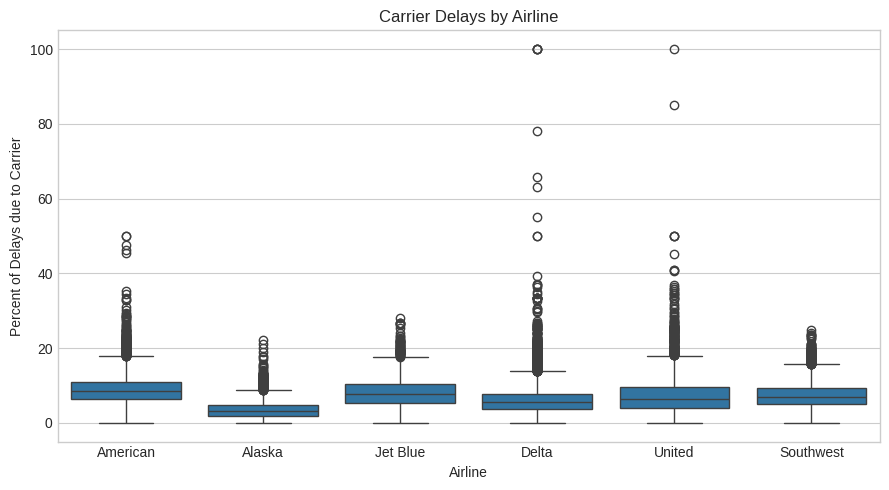

In [40]:
airline_stats = pd.read_csv('/content/airline_stats.csv')

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x='airline', y='pct_carrier_delay', data=airline_stats, ax=ax)
ax.set_xlabel('Airline')
ax.set_ylabel('Percent of Delays due to Carrier')
ax.set_title('Carrier Delays by Airline')
plt.tight_layout()
plt.show()